# Hyper-Parameter Optimisation

In this notebook we will build a simple pipeline to optimize the hyper-parameters of our architecture as well as of out training setup. For this purpose, we will use the hyper-parameter optimisation framework [Optuna](https://optuna.org/).

We will demonstrate how Optuna can help us to select the adequate hyper-parameters to aid our training process. We will use a subset of the classic MNIST dataset to demonstrate how it works.

In [1]:
import optuna
import numpy as np

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

### Dataset Preparation

Load the dataset, normalize it and extract a subset of it for both training and validation. We extract the subsets only for the sake of demonstration, so the training loops don't take too much time.

In [2]:
N_TRAIN_EXAMPLES = 600
N_VALID_EXAMPLES = 100
BATCHSIZE = 128
CLASSES = 10
EPOCHS = 10

# Load MNIST datase
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()
num_samples, rows, cols = x_train.shape

# Create training subset
x_train = x_train[:N_TRAIN_EXAMPLES, ..., np.newaxis]/255
y_train = y_train[:N_TRAIN_EXAMPLES]

# Create validation subset
x_valid = x_valid[:N_VALID_EXAMPLES, ..., np.newaxis]/255
y_valid = y_valid[:N_VALID_EXAMPLES]

INPUT_SHAPE = (rows, cols, 1)

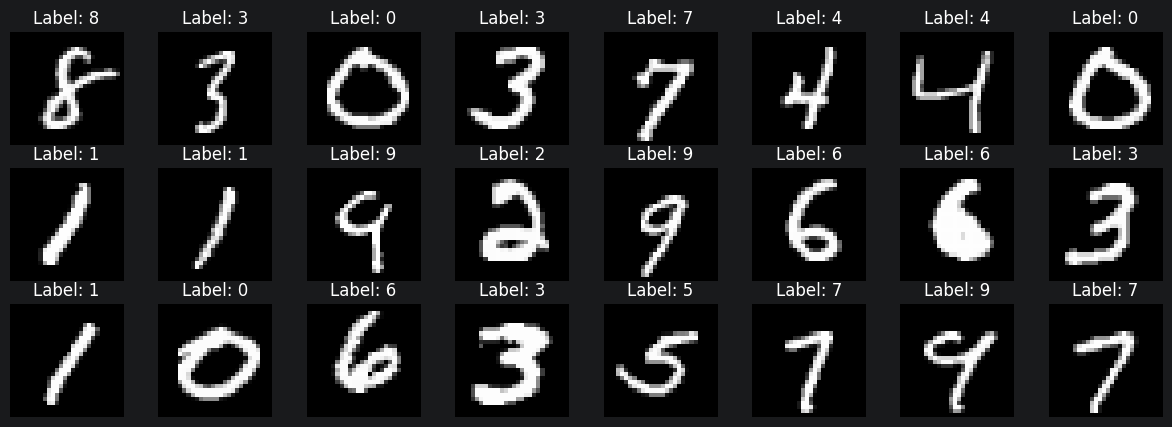

In [3]:
for cnt, idx in enumerate(np.random.randint(0, len(x_train), 24)):
    plt.subplot(3, 8, cnt+1), plt.imshow(x_train[idx, ...], cmap='gray')
    plt.axis(False), plt.title('Label: ' + str(y_train[idx]))

### Optuna Pipeline

In order to run a hyper-parameter search, we need to define an objective function. This function is a higher level abstraction of the actual loss function we use for tune the model parameters.

In [6]:
def objective(trial: optuna.Trial):
    """Objective function that controls the quality of the different runs.
    
    Args:
        trial (optuna.trial.Trial) Wrapper that controls the launching and the
            hyper-parameters of the different runs.
            
    Returns:
        (float) The quality metric of the current run.
        
    """    
    # Build model
    model = Sequential()
    model.add(
        Conv2D(
            filters=trial.suggest_categorical("filters", [32, 64]),
            kernel_size=trial.suggest_categorical("kernel_size", [3, 5]),
            strides=trial.suggest_categorical("strides", [1, 2]),
            activation=trial.suggest_categorical("activation", ["relu", "linear"]),
            input_shape=INPUT_SHAPE,
        )
    )
    model.add(Flatten())
    model.add(Dense(CLASSES, activation="softmax"))

    # Compile model with sampled learning rate.
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=RMSprop(learning_rate=learning_rate),
        metrics=["accuracy"],
    )
    accuracy = 0

    for epoch in range(EPOCHS):
        # Run training
        model.fit(x_train, y_train,
                  shuffle=True,
                  batch_size=BATCHSIZE,
                  epochs=1,
                  verbose=False,
                  validation_data=(x_valid, y_valid)
                  )
        # Evaluate model quality (performance on validation set)
        loss, accuracy = model.evaluate(x_valid, y_valid, verbose=0)

        trial.report(accuracy, step=epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return accuracy

# Pruning by Callback

In [ ]:
from optuna_integration.tfkeras import TFKerasPruningCallback

def objective(trial):
    model = Sequential()
    model.add(
        Conv2D(
            filters=trial.suggest_categorical("filters", [32, 64]),
            kernel_size=trial.suggest_categorical("kernel_size", [3, 5]),
            strides=trial.suggest_categorical("strides", [1, 2]),
            activation=trial.suggest_categorical("activation", ["relu", "linear"]),
            input_shape=INPUT_SHAPE,
        )
    )
    model.add(Flatten())
    model.add(Dense(CLASSES, activation="softmax"))

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=RMSprop(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    model.fit(
        x_train,
        y_train,
        shuffle=True,
        batch_size=BATCHSIZE,
        epochs=EPOCHS,
        verbose=False,
        validation_data=(x_valid, y_valid),
        callbacks=[TFKerasPruningCallback(trial, "val_accuracy")],
    )

    loss, accuracy = model.evaluate(x_valid, y_valid, verbose=0)
    return accuracy

### Run Hyper-Parameter Optimisation

In order to run the hyper-parameter optimisation we need to create a `study` object. It contains the main directives (and even the "hyper-hyper-parameters") of the pipeline.

In [7]:
# Create Optuna study
study = optuna.create_study(direction="maximize",
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
                                                               n_warmup_steps=2,
                                                               interval_steps=1))

# Launch hyper-parameter search
study.optimize(objective, n_trials=100)

print('Number of finished trials:', len(study.trials))

# Show detailed info about finished trials
study.trials_dataframe()

[I 2026-04-10 11:11:57,410] A new study created in memory with name: no-name-09b2a9de-38eb-42af-af5c-364769e03820
[I 2026-04-10 11:12:03,190] Trial 0 finished with value: 0.8700000047683716 and parameters: {'filters': 32, 'kernel_size': 3, 'strides': 1, 'activation': 'relu', 'learning_rate': 0.003975953113726114}. Best is trial 0 with value: 0.8700000047683716.
[I 2026-04-10 11:12:09,132] Trial 1 finished with value: 0.699999988079071 and parameters: {'filters': 32, 'kernel_size': 3, 'strides': 1, 'activation': 'linear', 'learning_rate': 5.0284663824004475e-05}. Best is trial 0 with value: 0.8700000047683716.
[I 2026-04-10 11:12:16,062] Trial 2 finished with value: 0.6299999952316284 and parameters: {'filters': 64, 'kernel_size': 5, 'strides': 1, 'activation': 'linear', 'learning_rate': 0.059355454299836304}. Best is trial 0 with value: 0.8700000047683716.
[I 2026-04-10 11:12:20,723] Trial 3 finished with value: 0.27000001072883606 and parameters: {'filters': 64, 'kernel_size': 5, 'str

Number of finished trials: 100


,number,value,datetime_start,datetime_complete,duration,params_activation,params_filters,params_kernel_size,params_learning_rate,params_strides,state
0,0,0.87,2026-04-10 11:11:57.411882,2026-04-10 11:12:03.189903,0 days 00:00:05.778021,relu,32,3,0.003976,1,COMPLETE
1,1,0.70,2026-04-10 11:12:03.191102,2026-04-10 11:12:09.132326,0 days 00:00:05.941224,linear,32,3,0.000050,1,COMPLETE
2,2,0.63,2026-04-10 11:12:09.133301,2026-04-10 11:12:16.062612,0 days 00:00:06.929311,linear,64,5,0.059355,1,COMPLETE
3,3,0.27,2026-04-10 11:12:16.063712,2026-04-10 11:12:20.723352,0 days 00:00:04.659640,linear,64,5,0.000011,2,COMPLETE
4,4,0.58,2026-04-10 11:12:20.724529,2026-04-10 11:12:25.334455,0 days 00:00:04.609926,relu,64,5,0.000045,2,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.92,2026-04-10 11:17:27.996619,2026-04-10 11:17:33.227447,0 days 00:00:05.230828,relu,32,5,0.003409,1,COMPLETE
96,96,0.83,2026-04-10 11:17:33.228601,2026-04-10 11:17:35.302474,0 days 00:00:02.073873,relu,32,5,0.004873,1,PRUNED
97,97,0.82,2026-04-10 11:17:35.303644,2026-04-10 11:17:37.437380,0 days 00:00:02.133736,linear,32,5,0.011104,1,PRUNED
98,98,0.83,2026-04-10 11:17:37.438198,2026-04-10 11:17:39.475586,0 days 00:00:02.037388,relu,32,5,0.014126,1,PRUNED


Show the optimisation metric for the different runs.

(Text(0.5, 0, 'trial'), Text(0, 0.5, 'metric'))

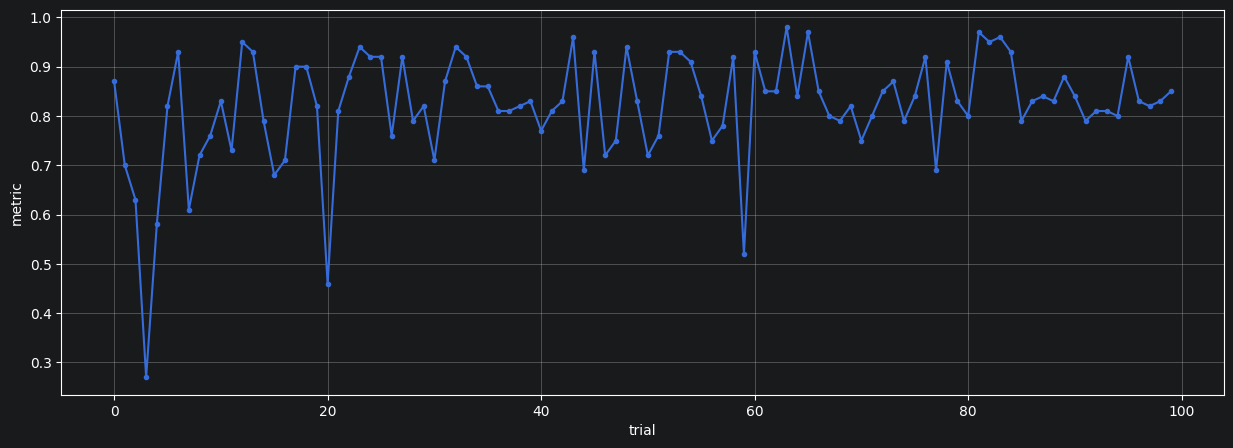

In [8]:
metrics = [trial.value for trial in study.trials]
plt.plot(metrics, '.-'), plt.grid(True)
plt.xlabel('trial'), plt.ylabel('metric')

Let's inspect the hyper-parameters for the best run.

In [9]:
# Show best trial
trial = study.best_trial
print('Best trial:', trial.number, '\n')
print('  Metric:', trial.value)
print('  Params:')
for key, value in trial.params.items():
    print('\t', key.ljust(13), ':', value)

Best trial: 63 

  Metric: 0.9800000190734863
  Params:
	 filters       : 32
	 kernel_size   : 5
	 strides       : 1
	 activation    : relu
	 learning_rate : 0.006436982396317491


In [10]:
# Show overall stats
mu = np.mean([trial.value for trial in study.trials])
std = np.std([trial.value for trial in study.trials])

print('Avg metric:', np.mean(mu))
print('Std metric:', np.mean(std))

Avg metric: 0.8208000016212463
Std metric: 0.11058643799529942


# Optuna Visualization

In [3]:
optuna.visualization.plot_optimization_history(study)

In [4]:
optuna.visualization.plot_parallel_coordinate(study)

In [5]:
optuna.visualization.plot_param_importances(study)